# polyline conversion
This section is all about turning the poly lines file into a array of json/dict elements that we can feed into the later steps

In [1]:
import json

In [2]:
import networkx as nx

In [3]:
import itertools

In [4]:
from pathlib import Path

In [5]:
# this file is newline delimited where each line is a sequence of points that are in a branch of the tree
polylines = Path("skel-poly.polylines.txt").read_text().split("\n")

In [6]:
# we need to iterate over the lines of the file which is a branch, and from that collect the values into groups of 3
# these are the coordinates x,y,z for a single point
vert_sets = []
for line in polylines:
    parts = line.strip().split(" ")[1:]
    vs=[]
    for i in range(0,len(parts),3):
        [x,y,z] = parts[i:i+3]
        vs.append({"x":float(x),"y":float(y),"z":float(z)})
    vert_sets.append(vs)
vert_sets

[[{'x': 0.337464, 'y': 0.0545325, 'z': 5.66947},
  {'x': 0.343796, 'y': 0.0555746, 'z': 5.67673},
  {'x': 0.359046, 'y': 0.0581846, 'z': 5.69304},
  {'x': 0.370663, 'y': 0.0602877, 'z': 5.70452},
  {'x': 0.390882, 'y': 0.0641331, 'z': 5.72338},
  {'x': 0.406726, 'y': 0.0674922, 'z': 5.73555}],
 [{'x': 0.629061, 'y': -1.25667, 'z': 6.00466},
  {'x': 0.62462, 'y': -1.25441, 'z': 6.01175},
  {'x': 0.614614, 'y': -1.24871, 'z': 6.02893},
  {'x': 0.60785, 'y': -1.24492, 'z': 6.04552},
  {'x': 0.599498, 'y': -1.24035, 'z': 6.06537},
  {'x': 0.596805, 'y': -1.23841, 'z': 6.07219},
  {'x': 0.586833, 'y': -1.22796, 'z': 6.09835},
  {'x': 0.583422, 'y': -1.22387, 'z': 6.1087},
  {'x': 0.579264, 'y': -1.20889, 'z': 6.13936},
  {'x': 0.575726, 'y': -1.19473, 'z': 6.1696},
  {'x': 0.577726, 'y': -1.17326, 'z': 6.20899}],
 [{'x': 0.249965, 'y': 0.0717785, 'z': 5.43966},
  {'x': 0.267876, 'y': 0.072204, 'z': 5.42557},
  {'x': 0.279455, 'y': 0.0739865, 'z': 5.40969},
  {'x': 0.287594, 'y': 0.0754676, 

In [7]:
# write this out in case we want to start from here later, or use on the web
Path("lines.json").write_text(json.dumps(vert_sets))

188459

In [8]:
lines = json.loads(Path("lines.json").read_text())

In [9]:
lines

[[{'x': 0.337464, 'y': 0.0545325, 'z': 5.66947},
  {'x': 0.343796, 'y': 0.0555746, 'z': 5.67673},
  {'x': 0.359046, 'y': 0.0581846, 'z': 5.69304},
  {'x': 0.370663, 'y': 0.0602877, 'z': 5.70452},
  {'x': 0.390882, 'y': 0.0641331, 'z': 5.72338},
  {'x': 0.406726, 'y': 0.0674922, 'z': 5.73555}],
 [{'x': 0.629061, 'y': -1.25667, 'z': 6.00466},
  {'x': 0.62462, 'y': -1.25441, 'z': 6.01175},
  {'x': 0.614614, 'y': -1.24871, 'z': 6.02893},
  {'x': 0.60785, 'y': -1.24492, 'z': 6.04552},
  {'x': 0.599498, 'y': -1.24035, 'z': 6.06537},
  {'x': 0.596805, 'y': -1.23841, 'z': 6.07219},
  {'x': 0.586833, 'y': -1.22796, 'z': 6.09835},
  {'x': 0.583422, 'y': -1.22387, 'z': 6.1087},
  {'x': 0.579264, 'y': -1.20889, 'z': 6.13936},
  {'x': 0.575726, 'y': -1.19473, 'z': 6.1696},
  {'x': 0.577726, 'y': -1.17326, 'z': 6.20899}],
 [{'x': 0.249965, 'y': 0.0717785, 'z': 5.43966},
  {'x': 0.267876, 'y': 0.072204, 'z': 5.42557},
  {'x': 0.279455, 'y': 0.0739865, 'z': 5.40969},
  {'x': 0.287594, 'y': 0.0754676, 

In [10]:
# checking if we can use this as a key in a dictionary
f"{lines[0][0]}"

"{'x': 0.337464, 'y': 0.0545325, 'z': 5.66947}"

In [11]:
# helpful package for things related to iteration, will use it for pairwise iteration later
import itertools

# Building a networkx graph
This lets us build paths out of the points between roots and leafs

In [12]:

# make an empty networkx graph
g = nx.Graph()

In [13]:
len(g.nodes)

0

In [14]:
# the cell underneath makes a map of the vertices so that we don't include any repeat ones when we make our graph
# n is the new id for the node in the graph

In [15]:
n=1
mp = {}
for i,l in enumerate(lines):
    for point in l:
        key = f"{point}"
        if mp.get(key,-1) !=-1:
            continue
        mp[key] =n
        n+=1

In [16]:
len(mp.keys())

3719

In [17]:
mp

{"{'x': 0.337464, 'y': 0.0545325, 'z': 5.66947}": 1,
 "{'x': 0.343796, 'y': 0.0555746, 'z': 5.67673}": 2,
 "{'x': 0.359046, 'y': 0.0581846, 'z': 5.69304}": 3,
 "{'x': 0.370663, 'y': 0.0602877, 'z': 5.70452}": 4,
 "{'x': 0.390882, 'y': 0.0641331, 'z': 5.72338}": 5,
 "{'x': 0.406726, 'y': 0.0674922, 'z': 5.73555}": 6,
 "{'x': 0.629061, 'y': -1.25667, 'z': 6.00466}": 7,
 "{'x': 0.62462, 'y': -1.25441, 'z': 6.01175}": 8,
 "{'x': 0.614614, 'y': -1.24871, 'z': 6.02893}": 9,
 "{'x': 0.60785, 'y': -1.24492, 'z': 6.04552}": 10,
 "{'x': 0.599498, 'y': -1.24035, 'z': 6.06537}": 11,
 "{'x': 0.596805, 'y': -1.23841, 'z': 6.07219}": 12,
 "{'x': 0.586833, 'y': -1.22796, 'z': 6.09835}": 13,
 "{'x': 0.583422, 'y': -1.22387, 'z': 6.1087}": 14,
 "{'x': 0.579264, 'y': -1.20889, 'z': 6.13936}": 15,
 "{'x': 0.575726, 'y': -1.19473, 'z': 6.1696}": 16,
 "{'x': 0.577726, 'y': -1.17326, 'z': 6.20899}": 17,
 "{'x': 0.249965, 'y': 0.0717785, 'z': 5.43966}": 18,
 "{'x': 0.267876, 'y': 0.072204, 'z': 5.42557}": 19,

In [18]:
# here we use pairwise iteration as we go over the lines so that we can add the nodes to the networks and make edges between them
for l in lines:
    for (start,end) in itertools.pairwise(l):
        s_id =mp[f"{start}"] # recall this resolves to the n value for the vertex 
        e_id = mp[f"{end}"]
        g.add_nodes_from([(s_id,start),(e_id,end)])
        g.add_edge(s_id,e_id)
        

In [19]:
list(g.nodes)

[1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,
 185

In [20]:
# we need to look for all the points that only have one connection to another, these will be the tips of the tree (roots, and leaves)
yvals = []
for n in g:
    if g.degree(n) ==1:
        attrs = nx.get_node_attributes(g,"y")
        yvals.append([n,attrs[n]]) # add the node identifier n and the y coordinate to a yvals list

In [21]:
#this will return only the y value when we sort the list
def sorted(x):
    return x[1]

In [22]:
# sort based on the y value element for each
yvals.sort(key=sorted)

In [23]:
yvals

[[7, -1.25667],
 [2716, -1.2273],
 [1292, -1.21856],
 [2717, -1.21823],
 [2694, -0.683607],
 [1240, -0.618103],
 [198, -0.605787],
 [3366, -0.604102],
 [2798, -0.559495],
 [740, -0.512219],
 [2754, -0.487526],
 [486, -0.427162],
 [752, -0.330391],
 [780, -0.302314],
 [1005, -0.298805],
 [3116, -0.279901],
 [788, -0.268554],
 [3086, -0.252322],
 [2264, -0.227905],
 [3035, -0.17527],
 [2368, -0.165235],
 [851, -0.145825],
 [862, -0.138699],
 [2171, -0.137049],
 [2025, -0.123742],
 [2625, -0.0473967],
 [951, -0.0425888],
 [1887, -0.0112755],
 [811, -0.00859495],
 [2379, 0.00109],
 [1933, 0.0107039],
 [2108, 0.0279671],
 [3244, 0.0299058],
 [791, 0.0402568],
 [764, 0.0482931],
 [795, 0.0534555],
 [1, 0.0545325],
 [3062, 0.0560632],
 [2024, 0.0614826],
 [702, 0.067089],
 [1476, 0.109868],
 [935, 0.118199],
 [993, 0.126642],
 [2837, 0.145387],
 [37, 0.156059],
 [971, 0.159488],
 [1615, 0.166558],
 [1589, 0.176504],
 [1274, 0.177723],
 [2017, 0.177878],
 [2114, 0.178155],
 [1705, 0.181768],
 

In [24]:
# get the nodes below -1 y, they are the roots of the tree
# NOTE when working with different 3d models this logic may need to change
# generate shortest paths from them
# add all of them to a list
roots = [e[0] for e in yvals[:4]]
roots

[7, 2716, 1292, 2717]

In [25]:
# the rest of the ids are the tips of the leaves
tips = [e[0] for e in yvals[4:]]
tips

[2694,
 1240,
 198,
 3366,
 2798,
 740,
 2754,
 486,
 752,
 780,
 1005,
 3116,
 788,
 3086,
 2264,
 3035,
 2368,
 851,
 862,
 2171,
 2025,
 2625,
 951,
 1887,
 811,
 2379,
 1933,
 2108,
 3244,
 791,
 764,
 795,
 1,
 3062,
 2024,
 702,
 1476,
 935,
 993,
 2837,
 37,
 971,
 1615,
 1589,
 1274,
 2017,
 2114,
 1705,
 1702,
 1197,
 2239,
 62,
 2656,
 2712,
 2164,
 1184,
 2078,
 2179,
 3423,
 1961,
 3415,
 2074,
 2937,
 73,
 3362,
 3437,
 3413,
 2635,
 1091,
 620,
 2993,
 3288,
 2567,
 340,
 730,
 418,
 2484,
 977,
 796,
 3397,
 1783,
 731,
 362,
 485,
 2755,
 1659,
 289,
 1506,
 367,
 940,
 355,
 1571,
 1925,
 732,
 2682,
 1923,
 1513,
 1844,
 1697,
 3434,
 266,
 1946,
 253,
 3280,
 1955,
 994,
 278,
 825,
 2063,
 2911,
 2515,
 84,
 627,
 3341,
 3137,
 3308,
 1086,
 2051,
 3122,
 1572,
 2336,
 2985,
 205,
 326,
 3289,
 3191,
 351,
 2369,
 1181,
 1874,
 2325,
 1122,
 3154,
 1563,
 616,
 3388,
 3468,
 2623,
 396,
 2454,
 1809,
 1706,
 2432,
 2721,
 1300,
 1803]

In [26]:
len(tips)

146

In [27]:
import tqdm

In [28]:
# Here's the most important part from this section
# we are using the shortest_path method to calculate the paths between roots and leaves
paths = []
pairings = [[r,t] for r in roots for t in tips]
for r,t in tqdm.tqdm(pairings):
    simple_paths = nx.shortest_path(g,r,t)
    # add to a structure that we can write out later, and use for .obj generation
    paths.append({"source":r,"target":t,"paths":list(itertools.pairwise(simple_paths))})
    # break # if we want to test we can uncomment this and only run one iteration

100%|███████████████████████████████████████| 584/584 [00:00<00:00, 1269.86it/s]


In [29]:
Path("test_path_export.json").write_text(json.dumps(paths))

903332

In [30]:
paths[0]

{'source': 7,
 'target': 2694,
 'paths': [(7, 8),
  (8, 9),
  (9, 10),
  (10, 11),
  (11, 12),
  (12, 13),
  (13, 14),
  (14, 15),
  (15, 16),
  (16, 17),
  (17, 1299),
  (1299, 2655),
  (2655, 2654),
  (2654, 2653),
  (2653, 2652),
  (2652, 2651),
  (2651, 2650),
  (2650, 2649),
  (2649, 1385),
  (1385, 2648),
  (2648, 2607),
  (2607, 2606),
  (2606, 2605),
  (2605, 2604),
  (2604, 2588),
  (2588, 2608),
  (2608, 2609),
  (2609, 2610),
  (2610, 2611),
  (2611, 2612),
  (2612, 2613),
  (2613, 2614),
  (2614, 2615),
  (2615, 2616),
  (2616, 2617),
  (2617, 2618),
  (2618, 2619),
  (2619, 2620),
  (2620, 2621),
  (2621, 2622),
  (2622, 2694)]}

In [31]:




# grab the attribute lists
x_attr = nx.get_node_attributes(g,"x")
y_attr = nx.get_node_attributes(g,"y")
z_attr = nx.get_node_attributes(g,"z")

# make a collection for the specific paths
vert_paths=[]
for p in paths:
    text = ""
    # this helps us only have one reference to the 3d coordinates per node id
    vert_row_map ={}
    # this is the node index we will track this so we can write out the vertices in the right order later
    n=0
    # iterate over the paths for each starting root
    # note these are the pairs of coordinates show above, they are the start and end point of a edge in the graph
    for nodes in p["paths"]:
        
        # for each node in the pair 
        for node_id in nodes:
            key = node_id
            # if this node id doesnt have coords in the map add them
            # is line returns -1 it means that node isn't in the map yet
            # if it is in the map we run into the continue part of the conditional
            if vert_row_map.get(key,-1) !=-1:
                continue
            x = x_attr[node_id]
            y = y_attr[node_id]
            z = z_attr[node_id]
            # make sure we can access the index of the node in the path in the value as well so we can write it out in order as .obj
            vert_row_map[key] =[n,x,y,z]
            # add one to the node index counter
            n+=1
    # add the path to the vertex paths
    vert_paths.append(vert_row_map)

In [32]:
# make a obj writer for each curve in the file that connects a root with a leaf

# can use i to map between the two lists vert_paths, and paths since they have the same order
for i,p in enumerate(paths):
    lines = ""
    verts = ""

    # lets write the vertex rows of the file first
    # get the collection of x,y,z points for this path and the order they should be written to the file
    vmap = vert_paths[i]
    for k,v in vmap.items():
        # note we use 1: to skip the first value in the list because that is the n value and we want to only have x,y,z in the row separated by ' '
        verts +=f"\nv {' '.join([str(e) for e in v[1:]])}"

    # now we will write the lines
    for start_id,end_id in p["paths"]:
        # use the vert_path_ map to get the right edge line values
        start_id_mapped = vmap[start_id][0]
        end_id_mapped = vmap[end_id][0]
        lines +=f"\nl {start_id_mapped} {end_id_mapped}"
    Path(f"test_verts_{i}.obj").write_text(verts+lines)



In [33]:
!rm test*.obj

## making simulation files

Here we will begin by outputting json files that can be visualized on the web

Then we will work on writing data out as animating files that work in blender

In [34]:
# start by making sort of a test file
import numpy as np

In [35]:
import json
from pathlib import Path 

In [36]:
# this makes a random data array where we have 100 time steps
# each time step is like a table of 500 rows with 3 columns x,y,z
timearr = np.random.random((100,500,3))

# write this out to json
Path("test.json").write_text(json.dumps([[{"x":e[0],"y":e[1],"z":e[2]} for e in arr ] for arr in timearr ]))

3890433

In [37]:
# make particles start at the beginning of one of the paths, and then with each time step they move to a new part on the path

x_attr = nx.get_node_attributes(g,"x")
y_attr = nx.get_node_attributes(g,"y")
z_attr = nx.get_node_attributes(g,"z")
# this can hold all the paths that the points go after we iterate over them in time

# the only way I could think to do this was first make tracks or a list of the x,y,z points that a particle is as it goes along a path


tracks=[]
# iterate over the paths
for path in paths:
    # get the pairs in a path
    point_pairs = path["paths"]

    # this will be the route a single point has to take, 
    # we can think of it as the steps in 3d space a particle traveling the path will take over time
    position_times = []

    # again start and end are node indices in the graph, just integer values
    for start,end in point_pairs:

        # we only need the start because the end will be a start in the next interation
        x = x_attr[start]
        y = y_attr[start]
        z = z_attr[start]
        # add the data as a dictionary element
        # this is easy to work with and convert to tables or arrays later
        position_times.append(dict(x=x,y=y,z=z))
    tracks.append(position_times)    

In [38]:
# this is how many branches there are in the tree
len(tracks)

584

In [39]:
# this is the length of the first branch in steps for a particle
len(tracks[0])

41

In [40]:
# the structure right now is
# tracks, then time
# we need to change to time, then tracks, this matches better our random data written out above as test.json

# we need to find the max length of all the tracks
max([len(e) for e in tracks])


158

In [41]:
# now we will iterate and collect the positions of each point at each time 
time_steps =[]
# i is sort of the time step (also the index into the position collections held in each track)
for i in range(158):
    # make somewhere we cna store the positions for this tiem
    positions =[]
    # iterate over the tracks
    for track in tracks:
        # make sure our current time isn't greater than the track has entries for
        if i < len(track):
            # if we have an entry, write it out
            positions.append(track[i])
    # add this collection of all the positions on all the branches to a time_step
    time_steps.append(positions)

In [42]:

# write this out for visualization prototyping
Path("test.json").write_text(json.dumps([[{"x":e["x"],"y":e["y"],"z":e["z"]} for e in arr ] for arr in time_steps ]))

2992262

In [43]:
import random

In [44]:
random.choice(range(20))

5

In [45]:
tracks[0]

[{'x': 0.629061, 'y': -1.25667, 'z': 6.00466},
 {'x': 0.62462, 'y': -1.25441, 'z': 6.01175},
 {'x': 0.614614, 'y': -1.24871, 'z': 6.02893},
 {'x': 0.60785, 'y': -1.24492, 'z': 6.04552},
 {'x': 0.599498, 'y': -1.24035, 'z': 6.06537},
 {'x': 0.596805, 'y': -1.23841, 'z': 6.07219},
 {'x': 0.586833, 'y': -1.22796, 'z': 6.09835},
 {'x': 0.583422, 'y': -1.22387, 'z': 6.1087},
 {'x': 0.579264, 'y': -1.20889, 'z': 6.13936},
 {'x': 0.575726, 'y': -1.19473, 'z': 6.1696},
 {'x': 0.577726, 'y': -1.17326, 'z': 6.20899},
 {'x': 0.557317, 'y': -1.14876, 'z': 6.23403},
 {'x': 0.56315, 'y': -1.12174, 'z': 6.23572},
 {'x': 0.561245, 'y': -1.10506, 'z': 6.2382},
 {'x': 0.559677, 'y': -1.07972, 'z': 6.23892},
 {'x': 0.558871, 'y': -1.05718, 'z': 6.23855},
 {'x': 0.558168, 'y': -1.03689, 'z': 6.23808},
 {'x': 0.557797, 'y': -1.01687, 'z': 6.23697},
 {'x': 0.557188, 'y': -0.979862, 'z': 6.23515},
 {'x': 0.557138, 'y': -0.955427, 'z': 6.23065},
 {'x': 0.557102, 'y': -0.930365, 'z': 6.21286},
 {'x': 0.560999,


## making the USD files
Here we convert our working simulation data to a format we can bring into blender automatically


In [188]:
import numpy as np

# Akshat TODO, read in the velocity data as pd dataframe
# pick a single column from the depths,
# normalize it
import matplotlib.pyplot as plt
import pandas as pd
df = pd.read_csv("sap_flow.csv")

df["date"] =pd.to_datetime(df['Datetime'], format='%m/%d/%Y %H:%M')

mid_speeds = df["Vc_15mm_cm/hr"]
mid_speeds


normalized
# note, look for another way to use the pandas series but with reindexing , unfortunately reset_index turns it into a whole dataframe again
# want to make the steps relative to a 2mm unit or .2 cm
# so we divide by .2 and that tells us the number of float steps, and then we floor the values
stepped = np.array((mid_speeds).dropna().astype("int16"))

stepped

array([12, 13, 12, ..., 11, 13, 12], shape=(14265,), dtype=int16)

In [181]:
mid_speeds

0     12.909282
1     13.061367
2     12.288562
3     11.654559
4     10.957115
        ...    
95    10.871298
96    11.928291
97    11.989773
98    11.649432
99    11.223155
Name: Vc_15mm_cm/hr, Length: 100, dtype: float64

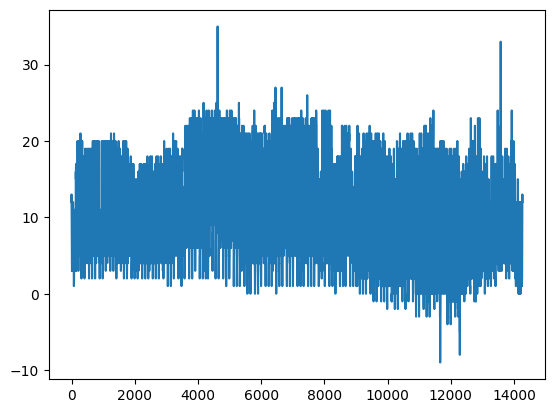

In [189]:
plt.plot(np.arange(stepped.shape[0]),stepped)

In [9]:
df.columns

Index(['Datetime', 'Vc_5mm_cm/hr', 'Vc_15mm_cm/hr', 'Vc_25mm_cm/hr', 'TreeID',
       'date'],
      dtype='object')

In [12]:
from pathlib import Path

In [13]:
Path("mid_data.json").write_text(df[['Vc_15mm_cm/hr',"date"]].to_json())

575919

In [49]:
tracks[0]

[{'x': 0.629061, 'y': -1.25667, 'z': 6.00466},
 {'x': 0.62462, 'y': -1.25441, 'z': 6.01175},
 {'x': 0.614614, 'y': -1.24871, 'z': 6.02893},
 {'x': 0.60785, 'y': -1.24492, 'z': 6.04552},
 {'x': 0.599498, 'y': -1.24035, 'z': 6.06537},
 {'x': 0.596805, 'y': -1.23841, 'z': 6.07219},
 {'x': 0.586833, 'y': -1.22796, 'z': 6.09835},
 {'x': 0.583422, 'y': -1.22387, 'z': 6.1087},
 {'x': 0.579264, 'y': -1.20889, 'z': 6.13936},
 {'x': 0.575726, 'y': -1.19473, 'z': 6.1696},
 {'x': 0.577726, 'y': -1.17326, 'z': 6.20899},
 {'x': 0.557317, 'y': -1.14876, 'z': 6.23403},
 {'x': 0.56315, 'y': -1.12174, 'z': 6.23572},
 {'x': 0.561245, 'y': -1.10506, 'z': 6.2382},
 {'x': 0.559677, 'y': -1.07972, 'z': 6.23892},
 {'x': 0.558871, 'y': -1.05718, 'z': 6.23855},
 {'x': 0.558168, 'y': -1.03689, 'z': 6.23808},
 {'x': 0.557797, 'y': -1.01687, 'z': 6.23697},
 {'x': 0.557188, 'y': -0.979862, 'z': 6.23515},
 {'x': 0.557138, 'y': -0.955427, 'z': 6.23065},
 {'x': 0.557102, 'y': -0.930365, 'z': 6.21286},
 {'x': 0.560999,

In [62]:
track_df = pd.DataFrame([{"x":e["x"],"y":e["y"],"z":e["z"],"track":i} for i,t in enumerate(tracks) for e in t])

In [63]:
track_df

,x,y,z,track
0,0.629061,-1.25667,6.00466,0
1,0.624620,-1.25441,6.01175,0
2,0.614614,-1.24871,6.02893,0
3,0.607850,-1.24492,6.04552,0
4,0.599498,-1.24035,6.06537,0
...,...,...,...,...
64615,0.214744,1.44289,6.38138,583
64616,0.209449,1.44861,6.37954,583
64617,0.202228,1.45766,6.37639,583
64618,0.196676,1.46495,6.37385,583


In [66]:
coord_df = track_df[["x","y","z"]]

In [56]:
min_dim = track_df.min(axis=0
                      )
min_dim

x   -0.592655
y   -1.256670
z    4.770160
dtype: float64

In [70]:
zero_centered = coord_df - min_dim

In [ ]:
center 

In [58]:
max_dim = track_df.max(axis=0)
max_dim

x    1.68968
y    1.47568
z    7.51016
dtype: float64

In [59]:
extents = max_dim - min_dim

In [60]:
extents

x    2.282335
y    2.732350
z    2.740000
dtype: float64

In [68]:
np.linalg.norm(extents)

np.float64(4.492481449569381)

In [73]:
normalized = zero_centered/np.linalg.norm(extents)

In [80]:
normalized["norm"] = np.linalg.norm(normalized,axis=1)

In [83]:
np.linalg.norm(normalized,axis=1)

array([0.54674667, 0.54735614, 0.54905122, ..., 1.02390402, 1.02500092,
       1.02669544], shape=(64620,))

In [82]:
normalized

,x,y,z,norm
0,0.271947,0.000000,0.274792,0.386608
1,0.270958,0.000503,0.276371,0.387039
2,0.268731,0.001772,0.280195,0.388238
3,0.267225,0.002615,0.283888,0.389883
4,0.265366,0.003633,0.288306,0.391858
...,...,...,...,...
64615,0.179722,0.600906,0.358648,0.722507
64616,0.178544,0.602179,0.358239,0.723072
64617,0.176936,0.604194,0.357537,0.724009
64618,0.175700,0.605817,0.356972,0.724785


<Axes: >

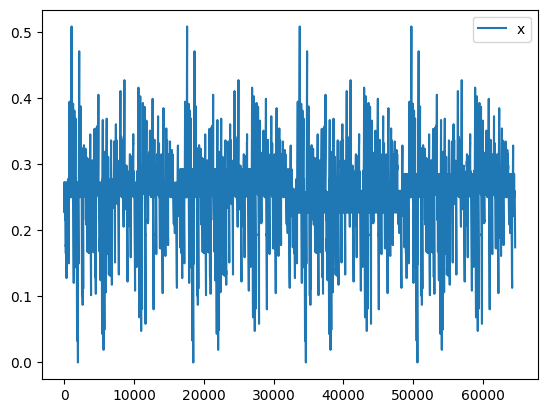

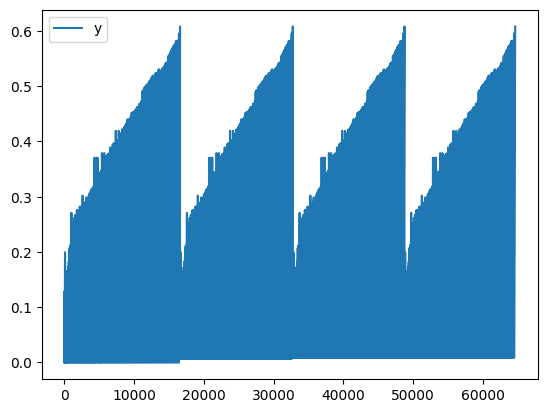

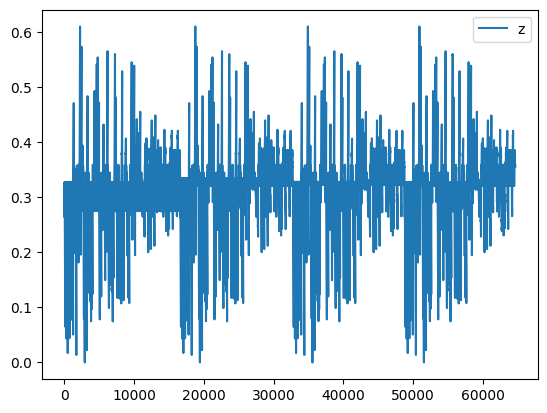

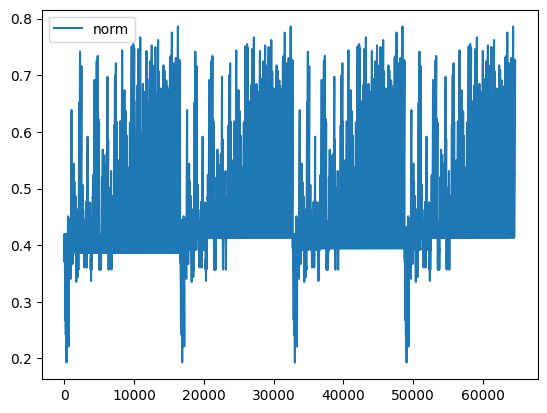

In [86]:
normalized.plot(y="x",use_index=True)
normalized.plot(y="y",use_index=True)
normalized.plot(y="z",use_index=True)
normalized.plot(y="norm",use_index =True)

In [92]:
# now find multiple that makes y go to 369 which is the total in cm that a tree gets
cm_scalar = 369/normalized.y.max()

In [93]:
cm_scalar

np.float64(606.7032608893813)

In [102]:
scaled_df = normalized[["x","y","z"]] * cm_scalar

In [108]:
scaled_df["step_distance"] = np.linalg.norm(scaled_df - scaled_df.shift(-1),axis=1)

In [111]:
# bring the track labels back in
scaled_df["track"]= track_df["track"]

<Axes: >

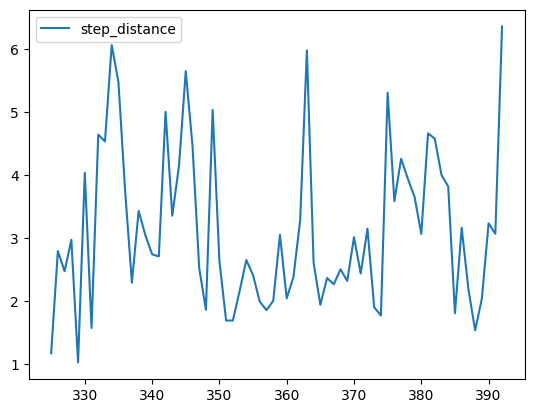

In [118]:
# checking to see how the natural jumps in the path measure in terms of cm
scaled_df[scaled_df.track ==4][:-1].plot(y="step_distance",use_index=True)

In [ ]:
# iterate over the tracks and on each make sure we have a point for each cm increment

<Axes: ylabel='Frequency'>

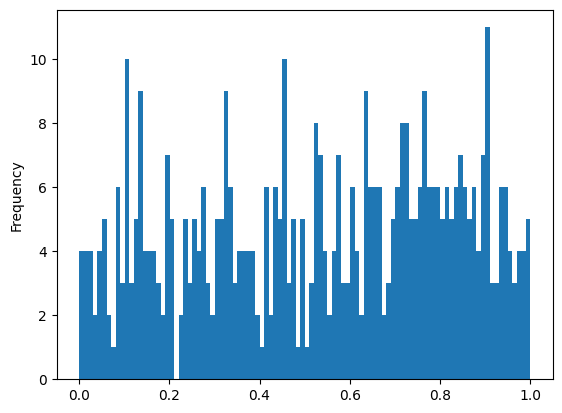

In [127]:
# working out the size of unit I should move by
df["Vc_15mm_cm/hr"].abs()[df["Vc_15mm_cm/hr"].abs() <1].plot.hist(bins=100)

In [128]:
# going down to about .2 mm seems appropriate because that's about the size of an ant, and we could imagine a very close view that needs to see that the motion never really stops

In [133]:
all_points = scaled_df.to_dict("records")

In [161]:
groups = []
track =[]
starting_track = all_points[0]["track"]
for point in all_points:
    current_track = point["track"]
    if current_track==starting_track:
        track.append(point)
    else:
        groups.append(track)
        track = [point]
        starting_track = current_track
# don't forget the last track
groups.append(track)
groups[0]

[{'x': 164.99101652423735,
  'y': 0.0,
  'z': 166.7174776291471,
  'step_distance': 1.1703203198636813,
  'track': 0},
 {'x': 164.39126576024296,
  'y': 0.3052098010869667,
  'z': 167.67497209361906,
  'step_distance': 2.7931313467670638,
  'track': 0},
 {'x': 163.0399696232181,
  'y': 1.0749867330320009,
  'z': 169.99510677621828,
  'step_distance': 2.4730633392699315,
  'track': 0},
 {'x': 162.12650099731,
  'y': 1.5868208684831637,
  'z': 172.23556279393196,
  'step_distance': 2.973104032784572,
  'track': 0},
 {'x': 160.9985752191337,
  'y': 2.203992899884699,
  'z': 174.91627719728436,
  'step_distance': 1.0243081174870083,
  'track': 0},
 {'x': 160.6348893809358,
  'y': 2.46598715391512,
  'z': 175.8373085439274,
  'step_distance': 4.035645994660582,
  'track': 0},
 {'x': 159.28818489578566,
  'y': 3.877244862481015,
  'z': 179.3701795158014,
  'step_distance': 1.5719418614967904,
  'track': 0},
 {'x': 158.8275341738796,
  'y': 4.429593573297701,
  'z': 180.7679323659121,
  'step

In [162]:
all_points[-1]

{'x': 105.61623108313354,
 'y': 369.0,
 'z': 216.06963236774203,
 'step_distance': nan,
 'track': 583}

In [163]:
len(groups)

584

In [168]:
subdivided_groups = []
for track in tqdm.tqdm(groups):
    # compare to the outer length
    # skip the last point
    subdivided = []
    points =[]
    for i,p in enumerate(track[:-1]):
        next_p = track[i+1]
        # make array vectors from the points
        arp = np.array([p["x"],p["y"],p["z"]])
        points.append(arp)
        arnp = np.array([next_p["x"],next_p["y"],next_p["z"]])
        # subtrack p from next_p make delta
        delta = arnp - arp
        # get delta magnitude use this in loop to determine ending criteria
        mag = np.linalg.norm(delta)
        # normalize the delta
        norm = delta/mag
        # scale it by .2 making scaled_norm
        scaled = norm*.2
        current = scaled
        current_mag = np.linalg.norm(current)
        increment = 1
        # make sure to get the starting point
        subdivided.append(arp)
            # check the resulting multiple of scaled norm against delta mag
        
        while current_mag < mag:
            # slowly make the vector we add to the starting p making bigger in steps of .2
            current = norm * .2*increment
            current_mag = np.linalg.norm(current)
            subdivided_point = arp + current
            increment +=1
            subdivided.append(subdivided_point)
        
        # stop at the end and 
    subdivided_groups.append(subdivided)
    # perhaps just add the final point in the data at the end or we can leave it off because that'll just be a 2mm shorter path

100%|█████████████████████████████████████████| 584/584 [00:11<00:00, 49.04it/s]


In [146]:
points = np.array(points)

In [143]:
import matplotlib.pyplot as plt

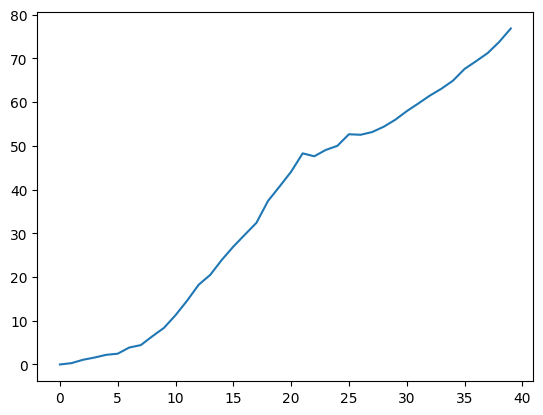

In [147]:
plt.plot(np.arange(points.shape[0]),points[:,1])

In [148]:
subdivided = np.array(subdivided)

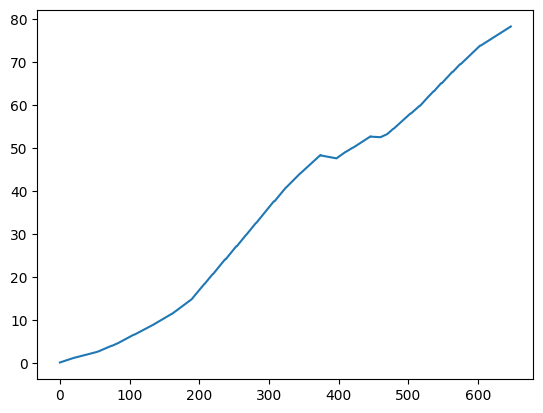

In [149]:
plt.plot(np.arange(subdivided.shape[0]),subdivided[:,1])

In [152]:
# now we will try to make the new subdivided data seem like what gets used in the simulation code below
tracks[0]

[{'x': 0.629061, 'y': -1.25667, 'z': 6.00466},
 {'x': 0.62462, 'y': -1.25441, 'z': 6.01175},
 {'x': 0.614614, 'y': -1.24871, 'z': 6.02893},
 {'x': 0.60785, 'y': -1.24492, 'z': 6.04552},
 {'x': 0.599498, 'y': -1.24035, 'z': 6.06537},
 {'x': 0.596805, 'y': -1.23841, 'z': 6.07219},
 {'x': 0.586833, 'y': -1.22796, 'z': 6.09835},
 {'x': 0.583422, 'y': -1.22387, 'z': 6.1087},
 {'x': 0.579264, 'y': -1.20889, 'z': 6.13936},
 {'x': 0.575726, 'y': -1.19473, 'z': 6.1696},
 {'x': 0.577726, 'y': -1.17326, 'z': 6.20899},
 {'x': 0.557317, 'y': -1.14876, 'z': 6.23403},
 {'x': 0.56315, 'y': -1.12174, 'z': 6.23572},
 {'x': 0.561245, 'y': -1.10506, 'z': 6.2382},
 {'x': 0.559677, 'y': -1.07972, 'z': 6.23892},
 {'x': 0.558871, 'y': -1.05718, 'z': 6.23855},
 {'x': 0.558168, 'y': -1.03689, 'z': 6.23808},
 {'x': 0.557797, 'y': -1.01687, 'z': 6.23697},
 {'x': 0.557188, 'y': -0.979862, 'z': 6.23515},
 {'x': 0.557138, 'y': -0.955427, 'z': 6.23065},
 {'x': 0.557102, 'y': -0.930365, 'z': 6.21286},
 {'x': 0.560999,

In [153]:
len(tracks)

584

In [165]:
len(subdivided_groups)

584

In [167]:
subdivided_groups[0]

[array([1.64888523e+02, 5.21583358e-02, 1.66881107e+02]),
 array([1.64786030e+02, 1.04316672e-01, 1.67044737e+02]),
 array([1.64683536e+02, 1.56475007e-01, 1.67208366e+02]),
 array([164.58104277,   0.20863334, 167.37199551]),
 array([164.47854934,   0.26079168, 167.53562498]),
 array([164.3760559 ,   0.31295001, 167.69925445]),
 array([164.29450725,   0.36032908, 167.84110353]),
 array([164.19774874,   0.41544836, 168.00723498]),
 array([164.10099023,   0.47056764, 168.17336642]),
 array([164.00423172,   0.52568692, 168.33949786]),
 array([163.90747321,   0.5808062 , 168.5056293 ]),
 array([163.8107147 ,   0.63592548, 168.67176074]),
 array([163.71395619,   0.69104476, 168.83789218]),
 array([163.61719768,   0.74616403, 169.00402362]),
 array([163.52043917,   0.80128331, 169.17015507]),
 array([163.42368066,   0.85640259, 169.33628651]),
 array([163.32692215,   0.91152187, 169.50241795]),
 array([163.23016364,   0.96664115, 169.66854939]),
 array([163.13340513,   1.02176043, 169.834680

In [170]:
tracks = [[{"x":e[0],"y":e[1],"z":e[2]} for e in track] for track in subdivided_groups]
# convert back to dictionary format


In [171]:
len(tracks[0])

688

In [192]:
del time_steps

In [193]:
del particles

In [194]:
import sys

print("{}{: >25}{}{: >10}{}".format('|','Variable Name','|','Memory','|'))
print(" ------------------------------------ ")
for var_name in dir():
    if not var_name.startswith("_"):
        print("{}{: >25}{}{: >10}{}".format('|',var_name,'|',sys.getsizeof(eval(var_name)),'|'))

|            Variable Name|    Memory|
 ------------------------------------ 
|                       In|      1656|
|                      Out|      4696|
|                     Path|       904|
|                      Sdf|        72|
|                      Usd|        72|
|                  UsdGeom|        72|
|                       Vt|        72|
|            add_particles|       144|
|          added_particles|     16184|
|               all_points|    562488|
|                 argparse|        72|
|                     arnp|       136|
|                      arp|       136|
|                      arr|       128|
|                    attrs|    147552|
|                cm_scalar|        32|
|                 coord_df|   1551024|
|          create_particle|       144|
|                  current|       136|
|              current_mag|        32|
|            current_track|        28|
|                    delta|       136|
|                       df|   2362094|
|                  df_nor

In [195]:
# so we need to increase the number of time steps to be as long as the csv data is
# in terms of veocity we might need to find a way to relate the scale of the model with number of steps along a path
# worry about that later

# need a way to think about the code from a "particle" perspective
# it would have a path it's on
# it would have a velocity (how many steps to move on the path)  
# 

# make the particle pick a path/track to start with using random choice 
timesteps= []
particles = []
def create_particle(tracks):
    track = random.choice(tracks)
    # NOTE this is probably something we want to base on the min and max values of the size of the tree, too much noise totally distorts the tree
    noise = np.random.random((3))/50
    return dict(
        track = track,
        # keep understandign of length of track
        track_length = len(track),
        starting_position = track[0],
        current_position = track[0],
        offset=noise,
        # note that we can track next position and then interpolate also
        index = 0
    )

# make a "move particles" function
# this function also potentially removes elements from the p_list
# will return a new list
def move_particles(p_list,series,simulation_step_index):
    new_list =[] 
    for particle in p_list:
        index = particle["index"]
        track =particle["track"]
        track_length = particle["track_length"]
        # if we can continue, particle hasn't fallen off the track
        # Akshat TODO, change the parts of the code that depend index +1 to be index+ some velocity mapped step [1,10]
        
        step_size = series[simulation_step_index]
        if index+step_size < track_length-1:
            # this is where we will think about stepping more than one index place through the track when velocity is higher
            # use the sca
            # Akshat TODO, change the parts of the code that depend index +1 to be index+ some velocity mapped step [1,10]
            
            next_index = index +step_size
            particle["current_position"] = track[next_index]
            particle["index"] = next_index
            # if we wanted to interpolate here's where we would get the next and then use some sort of parametric form
            new_list.append(particle)
    return new_list

    
def add_particles(p_list,number_to_add,tracks):
    new_particles = [create_particle(tracks) for i in range(number_to_add)]
    p_list.extend(new_particles)
    return p_list


# make a "take snapshot" function that gets all positions and writes them out to the 
def take_snapshot(tsteps,p_list):
    # injecting a little bit of noise
    tsteps.append([
        {
            "x": p["current_position"]["x"] + p["offset"][0], # could add more forces if we wanted to make more dynamic,
            "y":p["current_position"]["y"] + p["offset"][1],
            "z":p["current_position"]["z"] + p["offset"][2]
            
        }
        for p in p_list
    ])

simulation_steps = stepped.shape[0]//4
number_particles_to_start = 500
number_to_add_per_step=10
particles = add_particles(particles,number_particles_to_start,tracks)
for time_index in tqdm.tqdm(range(simulation_steps)):
    # move the particles
    moved_particles = move_particles(particles,stepped,time_index)
    particles = moved_particles
    # add new ones
    added_particles = add_particles(particles,number_to_add_per_step,tracks)
    particles = added_particles
    # snapshot
    take_snapshot(timesteps,particles)
    
# at the end make the output match the way the usdc write out pattern works
# have an array of time steps
# each time step has collection of point positions


len(timesteps)

len(timesteps[1])


import pandas as pd


# see if we can delete the previous stage, maeks it easier to work with cell iteratively
try:
    print(stage)
    del stage
except:
    pass

# this cell does a lot of work
from pxr import Usd,UsdGeom,Vt,Sdf
from pathlib import Path
import numpy as np
import argparse
# name our output file

100%|███████████████████████████████████████| 3566/3566 [00:38<00:00, 91.66it/s]


Usd.Stage.Open(rootLayer=Sdf.Find('/home/urche/Cacao_visualization/code/particle_simulation/subdivided_sap.usdc'), sessionLayer=Sdf.Find('anon:0x6006276ac700:subdivided_sap-session.usda'), pathResolverContext=Ar.ResolverContext(Ar.DefaultResolverContext(['/home/urche/Cacao_visualization/code/particle_simulation'])))


ImportError: cannot import name 'Patha' from 'pathlib' (/usr/lib/python3.10/pathlib.py)

In [196]:
name="subdivided_sap"
# create the variable we add points to, it's called a stage in usd
stage = Usd.Stage.CreateNew(f"{name}.usdc")
pts = UsdGeom.Points.Define(stage,"/mypoints")

import numpy as np

# get attributes we can write to
points = pts.GetPointsAttr()
widths = pts.GetWidthsAttr()

# establish the length of the timeseries
stage.SetStartTimeCode(0)
stage.SetEndTimeCode(len(timesteps))

# loop over our timesteps
for i,json_points in enumerate(timesteps):
    # if we end up attaching data to each poitn we will use these names
    # names = arr.dtype.names[3:]
    # pvars={}
    # arr[:,1], arr[:,2]


    # convert from list of dicts to a table, then to an array
    df = pd.DataFrame(json_points)
    arr = df.to_numpy()



    # write the array data to the attribute
    # print(arr)
    points.Set(time=i,value=Vt.Vec3fArray.FromNumpy(np.array([arr[:,0],arr[:,1],arr[:,2]]).T))


    # again we will use this later when we attach data to the points

    # for name in names:
    #   # skip the "_" prefaced names that stand for offset balancing in pcd binary
    #     if "skip" in name:
    #       continue
        # pvar = UsdGeom.PrimvarsAPI(pts).CreatePrimvar(name,Sdf.ValueTypeNames.FloatArray,"vertex")
        # pvar.Set(time=i,value= Vt.FloatArray(arr[name].astype("float64")))
        # pvars[name] = pvar
    

    

stage.Save()

In [66]:
len(timesteps)

14265

In [ ]:
json.dumps(timesteps)